In [6]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

notebook_dir = Path.cwd()
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

from utils.data import DataManager
from utils.analysis.risk_metrics import RiskAnalysis
from utils.analysis.risk_metrics.analyzers import (
    VarEsAnalyzer, 
    RatioAnalyzer, 
    ComprehensiveAnalyzer
)
from utils.analysis.risk_metrics.reporters import RiskReporter

In [7]:
data_manager = DataManager()
risk = RiskAnalysis(annual_factor=252)
ratio_analyzer = RatioAnalyzer(risk)
var_es_analyzer = VarEsAnalyzer(risk)
reporter = RiskReporter(risk)
ratio_analyzer = RatioAnalyzer(risk)

In [8]:
# Configuración
TICKERS = ["META"]  
BENCHMARK = "SP500"
START_DATE = "2020-01-01"
END_DATE = "2024-12-31"
RISK_FREE_RATE = 0.045
WEIGHTS = np.array([1.0])

In [9]:
assets_prices, benchmark_prices = data_manager.download_portfolio_with_benchmark(
    tickers=TICKERS,
    benchmark_name=BENCHMARK,
    start_date=START_DATE,
    end_date=END_DATE
)
returns = assets_prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

Descargando portafolio completo...
Descargando 1 ticker(s)...
Período: 2020-01-01 → 2024-12-31


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Descarga completada: 1257 observaciones

Descargando benchmark 'SP500' (^GSPC)...
Descargando 1 ticker(s)...
Período: 2020-01-01 → 2024-12-31
Descarga completada: 1257 observaciones

Portafolio descargado: 1 activos + benchmark
Fechas comunes: 1257



In [10]:
# Sharpe Ratio
sharpe = risk.sharpe.calculate(returns, WEIGHTS, RISK_FREE_RATE)
print(f"Sharpe Ratio: {sharpe:.3f}")

# Sortino Ratio
sortino = risk.sortino.calculate(returns, WEIGHTS, RISK_FREE_RATE)
print(f"Sortino Ratio: {sortino:.3f}")

# VaR 95% (histórico)
var_95 = risk.var.calculate(returns, WEIGHTS, 0.95, 'historical')
print(f"VaR 95% (diario): {var_95['var_daily_pct']:.2f}%")

# ES 95% (histórico)
es_95 = risk.es.calculate(returns, WEIGHTS, 0.95, 'historical')
print(f"ES 95% (diario): {es_95['es_daily_pct']:.2f}%")

Sharpe Ratio: 0.592
Sortino Ratio: 0.769
VaR 95% (diario): -4.02%
ES 95% (diario): -6.15%


In [11]:
comparison = var_es_analyzer.compare_methods(
    returns=returns,
    weights=WEIGHTS,
    confidence_level=0.95
)

print(comparison)

             VaR_daily_%  ES_daily_%  VaR_annual_%  ES_annual_%
method                                                         
Historical     -4.021105   -6.152450    -63.833062   -97.667121
Parametric     -4.528730   -5.710548    -71.891355   -90.652146
Monte_carlo    -4.611428   -5.794263    -73.204149   -91.981075


In [12]:
summary = reporter.print_full_report(
    returns=returns,
    weights=WEIGHTS,
    risk_free_rate=RISK_FREE_RATE,
    confidence_levels=(0.95, 0.99),
    var_method='historical'
)


REPORTE COMPLETO DE ANÁLISIS DE RIESGO

PERFORMANCE
Retorno anualizado:        31.09%
Volatilidad anualizada:    44.90%
Vol. Downside:             34.56%
RATIOS
Sharpe Ratio:              0.592
Sortino Ratio:             0.769
DISTRIBUCIÓN
Skewness:                 -0.297
Excess Kurtosis:          18.083
¿Normal?:                     No
VAR & ES
Método: Historical

95%:
  VaR:   -4.02%
  ES:    -6.15%

99%:
  VaR:   -6.43%
  ES:   -11.21%


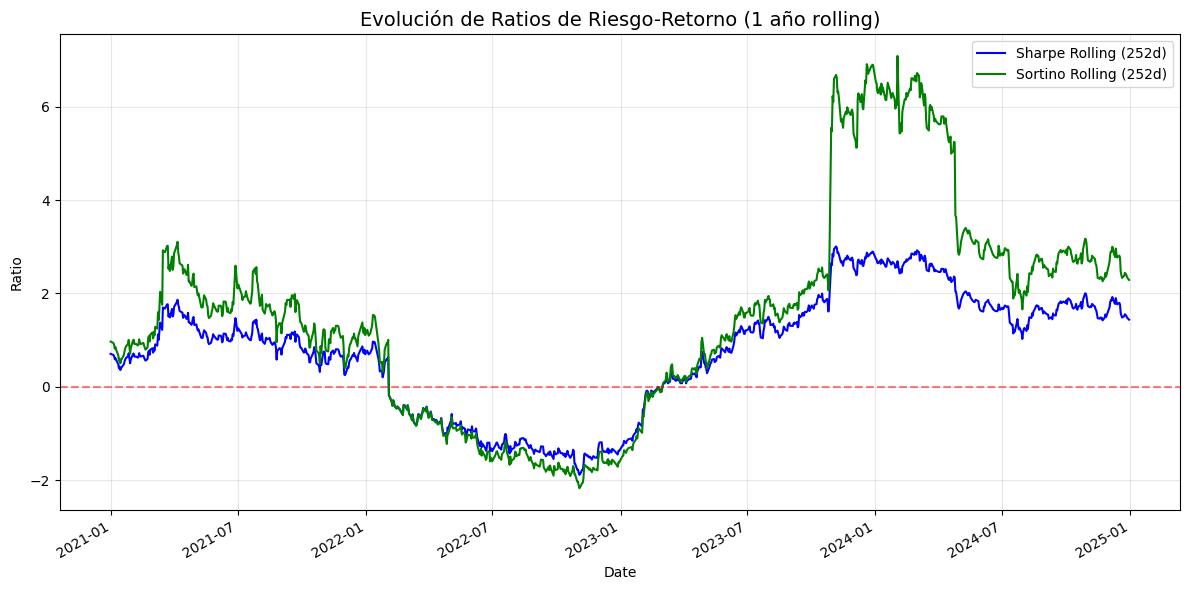

In [13]:
rolling_metrics = ratio_analyzer.calculate_rolling(
    returns=returns,
    weights=WEIGHTS,
    risk_free_rate=RISK_FREE_RATE,
    window=252  
)

# Visualizar Sharpe rolling
fig, ax = plt.subplots(figsize=(12, 6))
rolling_metrics['sharpe_rolling'].plot(ax=ax, label='Sharpe Rolling (252d)', color='blue')
rolling_metrics['sortino_rolling'].plot(ax=ax, label='Sortino Rolling (252d)', color='green')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Evolución de Ratios de Riesgo-Retorno (1 año rolling)', fontsize=14)
ax.set_ylabel('Ratio')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
dist_analysis = risk.moments.calculate_all(returns, WEIGHTS)

print(f"Skewness: {dist_analysis['skewness']:.3f}")
print(f"Excess Kurtosis: {dist_analysis['excess_kurtosis']:.3f}")
print(f"¿Es Normal? (JB test): {dist_analysis['is_normal']}")
print(f"JB p-value: {dist_analysis['jb_p_value']:.4f}")


Skewness: -0.297
Excess Kurtosis: 18.083
¿Es Normal? (JB test): False
JB p-value: 0.0000


In [15]:
multi_results = var_es_analyzer.calculate_multi_level(
    returns=returns,
    weights=WEIGHTS,
    confidence_levels=(0.90, 0.95, 0.99),
    methods=['historical', 'parametric']
)

for conf_level, methods_dict in multi_results.items():
    print(f"\n📊 Nivel de confianza: {conf_level*100:.0f}%")
    for method, metrics in methods_dict.items():
        print(f"  {method.capitalize()}:")
        print(f"    VaR diario: {metrics['var_daily_pct']:.2f}%")
        print(f"    ES diario:  {metrics['es_daily_pct']:.2f}%")



📊 Nivel de confianza: 90%
  Historical:
    VaR diario: -2.63%
    ES diario:  -4.74%
  Parametric:
    VaR diario: -3.50%
    ES diario:  -4.84%

📊 Nivel de confianza: 95%
  Historical:
    VaR diario: -4.02%
    ES diario:  -6.15%
  Parametric:
    VaR diario: -4.53%
    ES diario:  -5.71%

📊 Nivel de confianza: 99%
  Historical:
    VaR diario: -6.43%
    ES diario:  -11.21%
  Parametric:
    VaR diario: -6.46%
    ES diario:  -7.41%
